In [17]:
import pandas as pd

In [18]:
df = pd.read_csv('events_data.csv')
df

,Event ID,PageViews,Visitors,Registrations,Checkins
0,11/15/2023,642,536,180,89
1,2/8/2023,540,428,157,81
2,6/14/2023,271,220,119,64
3,7/16/2025,226,185,57,48
4,2/21/2024,495,410,148,85
5,3/13/2024,364,310,119,72
6,4/10/2024,427,370,136,84
7,6/12/2024,463,403,128,65
8,7/10/2024,249,192,215,73
9,8/14/2024,295,232,90,44


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Event ID       18 non-null     object
 1   PageViews      18 non-null     int64 
 2   Visitors       18 non-null     int64 
 3   Registrations  18 non-null     int64 
 4   Checkins       18 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 852.0+ bytes


In [20]:
df.describe()

,PageViews,Visitors,Registrations,Checkins
count,18.000000,18.000000,18.000000,18.000000
mean,347.277778,286.333333,102.666667,56.166667
std,122.183953,103.187437,49.901079,20.745659
min,209.000000,171.000000,44.000000,28.000000
25%,258.500000,216.750000,58.250000,39.500000
50%,303.000000,239.000000,85.000000,49.500000
75%,418.750000,356.000000,134.000000,72.750000
max,642.000000,536.000000,215.000000,89.000000


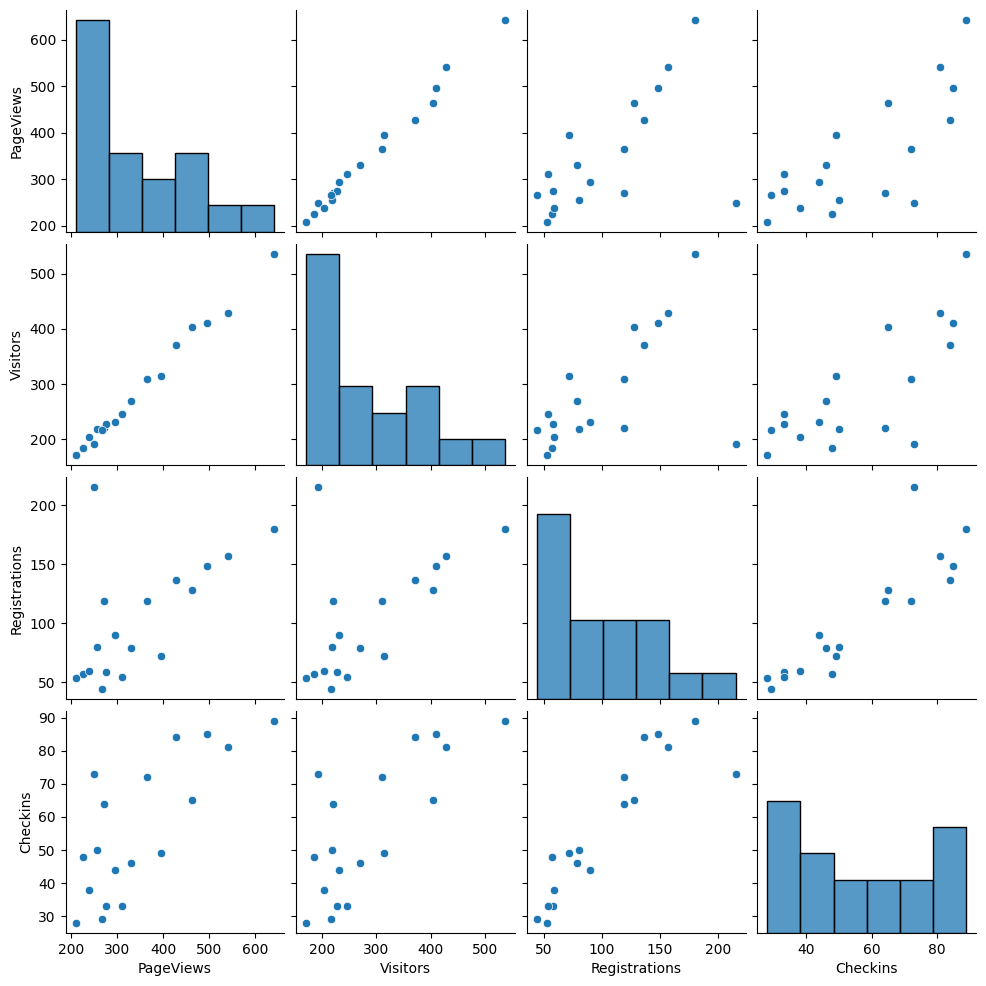

In [21]:
import seaborn as sns
sns.pairplot(df)

<Axes: >

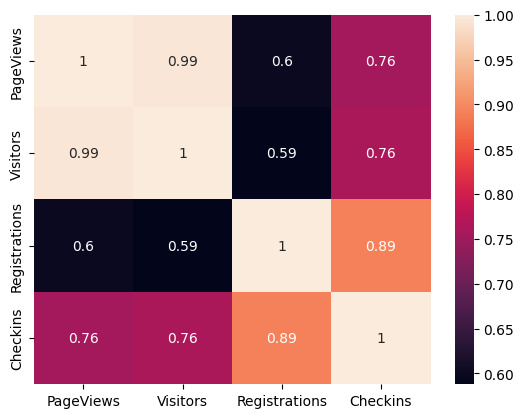

In [23]:
# Lets take at look at the correlation between variables

df = df.drop(['Event ID'] , axis = 1)

sns.heatmap(df.corr() , annot= True)


In [28]:
df['Registrations'].corr(df['Checkins'])

0.8921000633620743

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Using Simple LinearRegression

In [31]:
# 2. Features & target
X = df[['PageViews', 'Visitors', 'Registrations']]
y = df['Checkins']

# 3. Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Train model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predictions & evaluation
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# 6. Predict for new upcoming event
new_event = [[226, 185, 57]]  # Example features
predicted_checkins = model.predict(new_event)
print("Predicted Check-ins:", int(predicted_checkins[0]))

MAE: 13.9026085902489
R²: -6.70086545115736
Predicted Check-ins: 35


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Using  RandomForestRegressor

In [33]:
from sklearn.ensemble import RandomForestRegressor

model1 = RandomForestRegressor(n_estimators=200, random_state=42)
model1.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MAE: 5.6012499999999985
R²: 0.14933602649006605


In [34]:
# 6. Predict for new upcoming event
new_event = [[226, 185, 57]]  # Example features
predicted_checkins = model1.predict(new_event)
print("Predicted Check-ins:", int(predicted_checkins[0]))

Predicted Check-ins: 42


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


# Using Gradient Boosting Regressor

In [35]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Create and train model
gbr = GradientBoostingRegressor(
    n_estimators=300,       # Number of boosting stages
    learning_rate=0.05,     # Step size shrinkage
    max_depth=4,            # Depth of individual trees
    random_state=42
)
gbr.fit(X_train, y_train)

# Predictions
y_pred_gbr = gbr.predict(X_test)

# Evaluation
print("GradientBoosting MAE:", mean_absolute_error(y_test, y_pred_gbr))
print("GradientBoosting R²:", r2_score(y_test, y_pred_gbr))

GradientBoosting MAE: 6.812772985040251
GradientBoosting R²: -0.17927287627832555


In [36]:
# 6. Predict for new upcoming event
new_event = [[226, 185, 57]]  # Example features
predicted_checkins = gbr.predict(new_event)
print("Predicted Check-ins:", int(predicted_checkins[0]))

Predicted Check-ins: 47


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


# Now Using XGBRegressor 

In [37]:
from xgboost import XGBRegressor

# Create and train model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Evaluation
print("XGBRegressor MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGBRegressor R²:", r2_score(y_test, y_pred_xgb))


XGBRegressor MAE: 7.17967414855957
XGBRegressor R²: -0.49345039366127685


In [38]:
# 6. Predict for new upcoming event
new_event = [[226, 185, 57]]  # Example features
predicted_checkins = xgb.predict(new_event)
print("Predicted Check-ins:", int(predicted_checkins[0]))

Predicted Check-ins: 47


# Confidence Interval for my XGBRegressor model using the bootstrap technique

In [ ]:
import numpy as np
from sklearn.utils import resample
from xgboost import XGBRegressor

# Parameters
n_bootstrap = 100  # Number of bootstrap samples
predictions = []

# Bootstrap loop
for i in range(n_bootstrap):
    # Resample training data with replacement
    X_resampled, y_resampled = resample(X_train, y_train, random_state=i)
    
    # Train model
    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    xgb.fit(X_resampled, y_resampled)
    
    # Predict for the new event
    new_event = [[226, 185, 57]]
    predictions.append(xgb.predict(new_event)[0])

# Calculate point estimate and 95% confidence interval
pred_mean = np.mean(predictions)
pred_lower = np.percentile(predictions, 2.5)
pred_upper = np.percentile(predictions, 97.5)

print(f"Predicted Check-ins: {pred_mean:.1f}")
print(f"95% CI: [{pred_lower:.1f}, {pred_upper:.1f}]")

